<a href="https://colab.research.google.com/github/jeniferGoncalvesDaSilvaDev/Introdu-o-Aprendizagem-por-Refor-o/blob/main/revis%C3%A3o_e_greedy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Funcionamento de E-greedy

Minha abordagem: utilizei a distribuição beta binomial para modelar a probabilidade de sucesso do agente de obter o valor esperado da recompensa, no caso do e-greedy argmax(Q(t))

Avaliar a probabilidade de sucesso do agente ao obter o melhor esperado da recompensa ao ir para a direita ou esquerda

Iniciando simulação ε-greedy com estimativa Q e Beta-Binomial...

Simulação concluída.



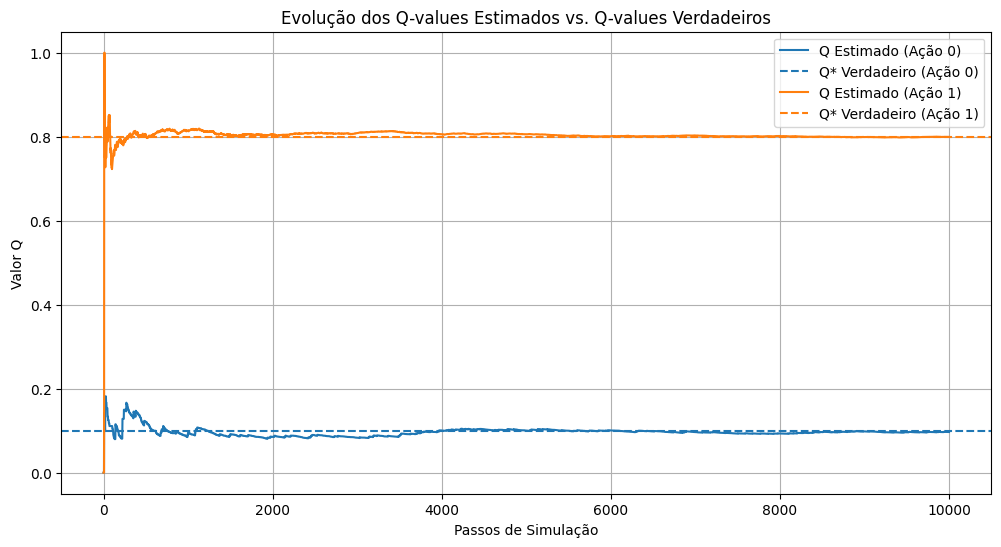

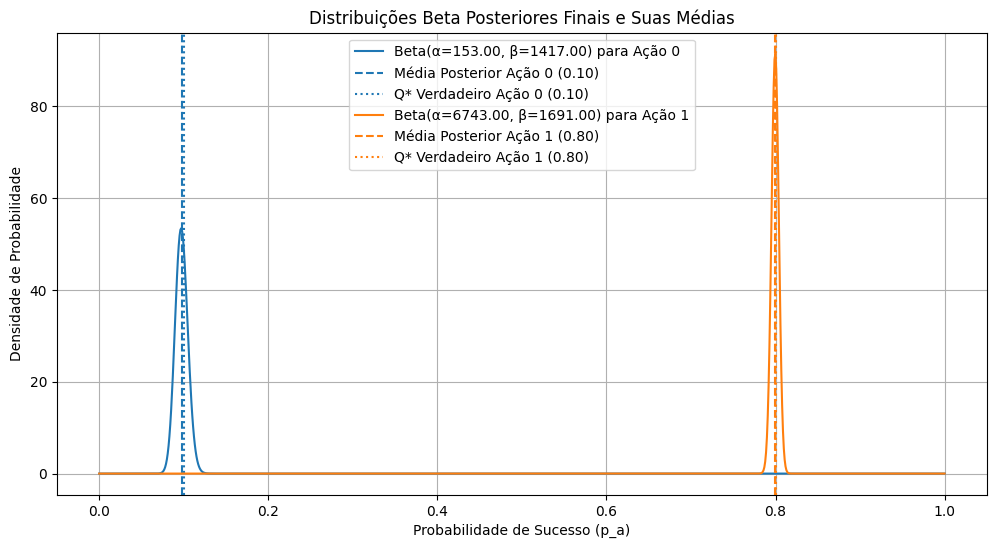

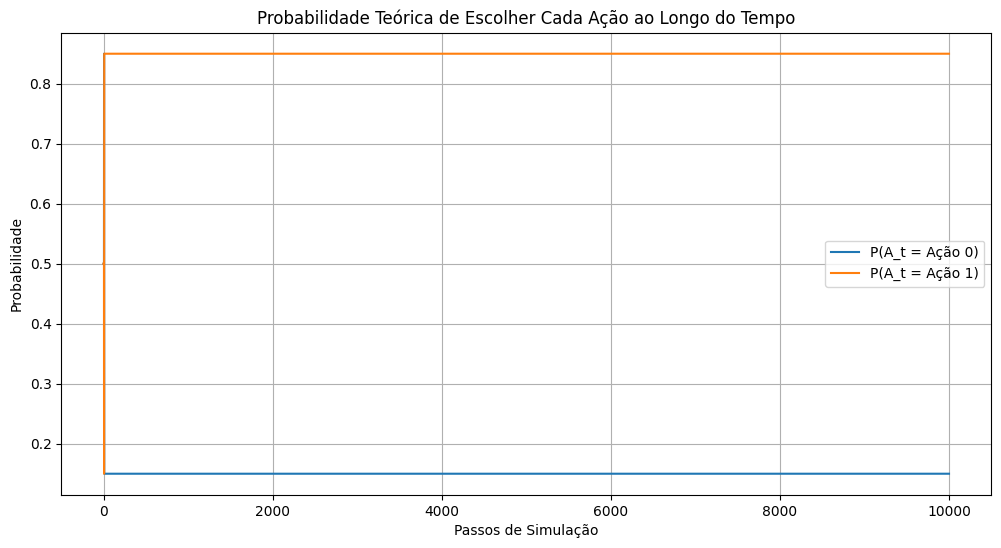

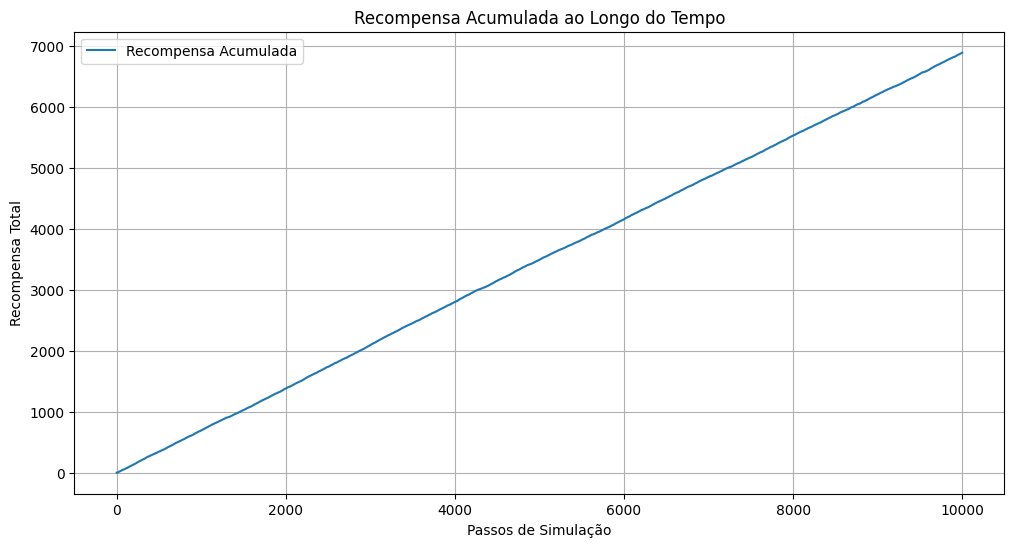

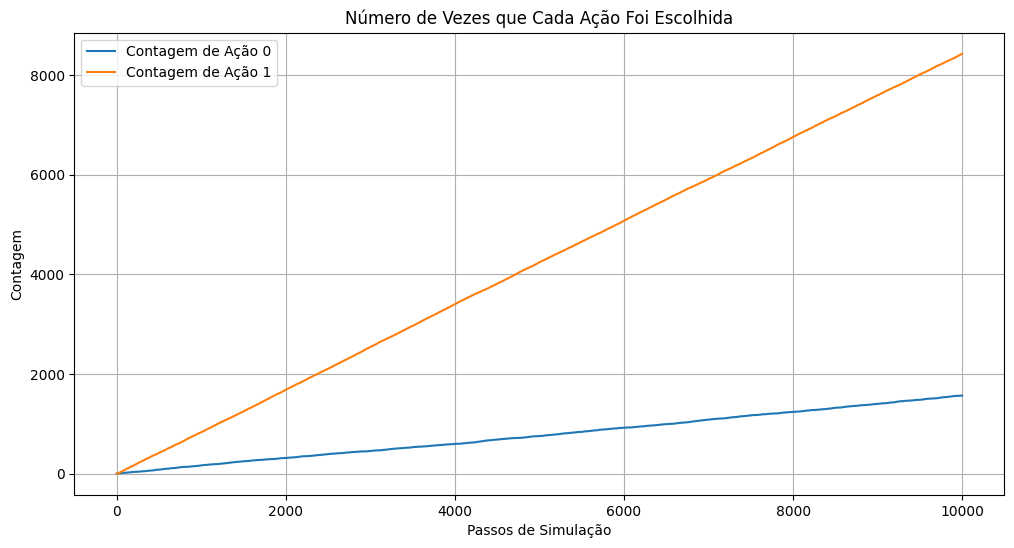

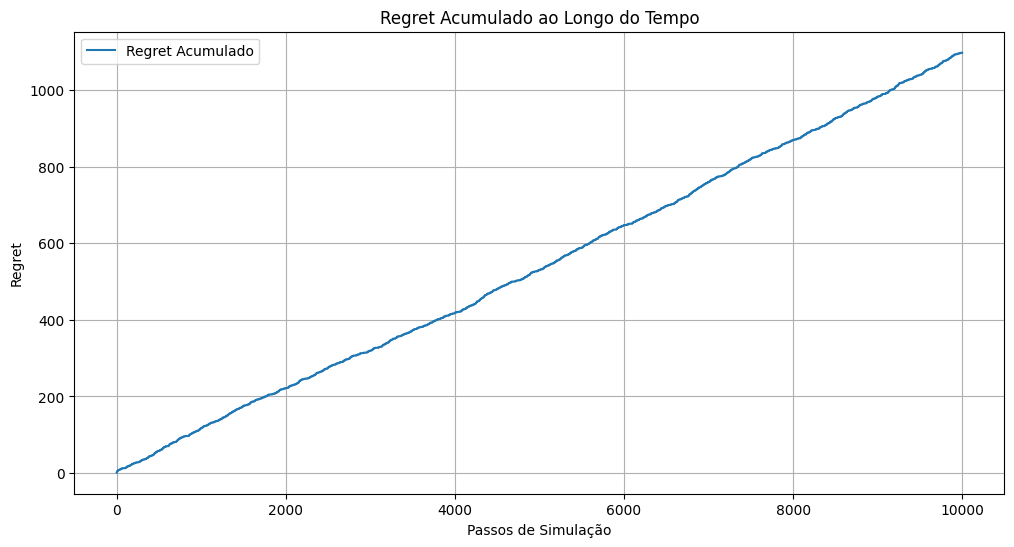


--- Comparação entre Estimativa Frequentista (Q) e Bayesiana (Beta) ---
No caso de recompensas Bernoulli, o Q-valor frequentista (média amostral das recompensas)
e a média da distribuição Beta posterior (E[p_a|D]) estimam a mesma quantidade: p_a = E[R|A=a].

No entanto:
  - Q(a) é uma estimativa pontual do valor esperado da recompensa.
  - A distribuição Beta(α,β) representa a crença e a incerteza sobre a verdadeira probabilidade de sucesso p_a.
    Conforme a ação é tomada mais vezes (N(a) aumenta), a distribuição Beta se torna mais estreita,
    indicando uma redução da incerteza sobre p_a, convergindo para o valor verdadeiro.
    Isso é visível no GRÁFICO 2, onde as distribuições ficam mais concentradas.

IMPORTANTE: A conjugação Beta-Binomial é apropriada especificamente para recompensas Bernoulli/Binomiais.
Para recompensas com outras distribuições (ex: Normal), outros modelos Bayesianos seriam necessários.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats # Adicionado para plotagem da distribuição Beta

def select_action_epsilon_greedy(Q_values, epsilon, num_actions):
    """
    Seleciona uma ação usando uma política epsilon-greedy para um Multi-Armed Bandit.
    Assume que Q_values é um array 1D de valores Q para cada ação.
    """
    if np.random.rand() < epsilon:
        return np.random.randint(num_actions)  # Explorar: Escolher uma ação aleatória
    else:
        # Explorar: Escolher a ação com o maior Q-valor
        max_q = np.max(Q_values)
        # Obter todas as ações que têm o Q-valor máximo (para lidar com empates)
        greedy_actions = np.where(Q_values == max_q)[0]
        return np.random.choice(greedy_actions) # Escolher aleatoriamente entre as melhores ações


# --- Configuração da Simulação (pontos 12 e 13 da descrição do problema) ---

num_actions = 2  # Número de ações/braços do bandit (k)
true_probs = np.array([0.1, 0.8]) # Probabilidades verdadeiras de sucesso para cada ação
epsilon_value = 0.3 # Probabilidade de exploração (epsilon)
steps = 10000 # Número de passos da simulação

# Q-values frequentistas
Q = np.zeros(num_actions) # Estimativa de valor Q de cada ação
N = np.zeros(num_actions) # Contador de quantas vezes cada ação foi escolhida

# Parâmetros da distribuição Beta (Bayesiana)
# Inicializar com prior uniforme Beta(1,1) para cada ação (ponto 6)
alpha = np.ones(num_actions)
beta = np.ones(num_actions)

# Históricos para plotagem (ponto 14, PASSO 6 e ponto 15)
Q_history = np.zeros((steps, num_actions))
alpha_history = np.zeros((steps, num_actions))
beta_history = np.zeros((steps, num_actions))
chosen_actions_history = np.zeros(steps, dtype=int)
rewards_history = np.zeros(steps)
prob_chosen_action_history = np.zeros((steps, num_actions)) # Probabilidade teórica de escolher cada ação

# Para o cálculo de Regret (ponto 15, GRÁFICO 6)
optimal_true_q = np.max(true_probs) # Q*(a*) = max(p_a)
regret_per_step = np.zeros(steps)

print("Iniciando simulação ε-greedy com estimativa Q e Beta-Binomial...\n")

# --- Loop Principal da Simulação (ponto 14) ---
for t in range(steps):
    # PASSO 1: Selecionar ação usando ε-greedy
    action = select_action_epsilon_greedy(Q, epsilon_value, num_actions)
    chosen_actions_history[t] = action

    # PASSO 2: Gerar recompensa (R_t ~ Bernoulli(p_a)) (ponto 7)
    reward = 1 if np.random.rand() < true_probs[action] else 0
    rewards_history[t] = reward

    # PASSO 3: Atualizar N(a)
    N[action] += 1

    # PASSO 4: Atualizar Q(a) (média incremental) (ponto 2)
    Q[action] += (reward - Q[action]) / N[action]

    # PASSO 5: Atualizar Beta (parâmetros alpha e beta) (ponto 7)
    if reward == 1:
        alpha[action] += 1
    else:
        beta[action] += 1

    # PASSO 6: Salvar histórico
    Q_history[t] = Q.copy()
    alpha_history[t] = alpha.copy()
    beta_history[t] = beta.copy()

    # Calcular e salvar a probabilidade de escolher cada ação para o GRÁFICO 3 (ponto 11)
    max_q_current = np.max(Q)
    greedy_actions_current = np.where(Q == max_q_current)[0]
    m_tied_actions = len(greedy_actions_current)

    for i in range(num_actions):
        if i in greedy_actions_current:
            # P(A_t = a) = (1-ε)*(1/m) + ε/k (considerando empates, ponto 5)
            prob_chosen_action_history[t, i] = (1 - epsilon_value) * (1 / m_tied_actions) + epsilon_value / num_actions
        else:
            # P(A_t = a) = ε/k
            prob_chosen_action_history[t, i] = epsilon_value / num_actions

    # Calcular Regret para o GRÁFICO 6 (ponto 15)
    regret_per_step[t] = optimal_true_q - true_probs[action]

print("Simulação concluída.\n")

# --- Plotagem dos Resultados (ponto 15) ---

# GRÁFICO 1: Q(a) ao longo do tempo (frequentista)
plt.figure(figsize=(12, 6))
for i in range(num_actions):
    plt.plot(Q_history[:, i], label=f'Q Estimado (Ação {i})')
    plt.axhline(y=true_probs[i], linestyle='--', color=f'C{i}', label=f'Q* Verdadeiro (Ação {i})') # Adiciona o Q* verdadeiro
plt.title('Evolução dos Q-values Estimados vs. Q-values Verdadeiros')
plt.xlabel('Passos de Simulação')
plt.ylabel('Valor Q')
plt.legend()
plt.grid(True)
plt.show()

# GRÁFICO 2: Distribuição Beta posterior de cada ação (Bayesiana) (ponto 8 e 17)
plt.figure(figsize=(12, 6))
x = np.linspace(0, 1, 1000)
for i in range(num_actions):
    # Parâmetros finais da Beta
    final_alpha = alpha_history[-1, i]
    final_beta = beta_history[-1, i]

    # Distribuição Beta
    pdf = stats.beta.pdf(x, final_alpha, final_beta)
    plt.plot(x, pdf, label=f'Beta(α={final_alpha:.2f}, β={final_beta:.2f}) para Ação {i}')

    # Média posterior E[p_a | D] = α / (α + β) (ponto 8)
    mean_posterior = final_alpha / (final_alpha + final_beta)
    plt.axvline(x=mean_posterior, color=f'C{i}', linestyle='--', label=f'Média Posterior Ação {i} ({mean_posterior:.2f})')

    # Q* verdadeiro
    plt.axvline(x=true_probs[i], color=f'C{i}', linestyle=':', label=f'Q* Verdadeiro Ação {i} ({true_probs[i]:.2f})')

plt.title('Distribuições Beta Posteriores Finais e Suas Médias')
plt.xlabel('Probabilidade de Sucesso (p_a)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True)
plt.show()

# GRÁFICO 3: Probabilidade de escolher cada ação ao longo do tempo (ponto 11)
plt.figure(figsize=(12, 6))
for i in range(num_actions):
    plt.plot(prob_chosen_action_history[:, i], label=f'P(A_t = Ação {i})')
plt.title('Probabilidade Teórica de Escolher Cada Ação ao Longo do Tempo')
plt.xlabel('Passos de Simulação')
plt.ylabel('Probabilidade')
plt.legend()
plt.grid(True)
plt.show()

# GRÁFICO 4: Recompensa acumulada
plt.figure(figsize=(12, 6))
cumulative_reward = np.cumsum(rewards_history)
plt.plot(cumulative_reward, label='Recompensa Acumulada')
plt.title('Recompensa Acumulada ao Longo do Tempo')
plt.xlabel('Passos de Simulação')
plt.ylabel('Recompensa Total')
plt.legend()
plt.grid(True)
plt.show()

# GRÁFICO 5: Número de vezes que cada ação foi escolhida
plt.figure(figsize=(12, 6))
# np.bincount é mais eficiente para contar ocorrências
N_history = np.array([np.bincount(chosen_actions_history[:t+1], minlength=num_actions) for t in range(steps)])
for i in range(num_actions):
    plt.plot(N_history[:, i], label=f'Contagem de Ação {i}')
plt.title('Número de Vezes que Cada Ação Foi Escolhida')
plt.xlabel('Passos de Simulação')
plt.ylabel('Contagem')
plt.legend()
plt.grid(True)
plt.show()

# GRÁFICO 6: Regret acumulado
plt.figure(figsize=(12, 6))
cumulative_regret = np.cumsum(regret_per_step)
plt.plot(cumulative_regret, label='Regret Acumulado')
plt.title('Regret Acumulado ao Longo do Tempo')
plt.xlabel('Passos de Simulação')
plt.ylabel('Regret')
plt.legend()
plt.grid(True)
plt.show()

# --- Comparação entre Q e Bayes (pontos 16, 17 e 18) ---
print("\n--- Comparação entre Estimativa Frequentista (Q) e Bayesiana (Beta) ---")
print("No caso de recompensas Bernoulli, o Q-valor frequentista (média amostral das recompensas)")
print("e a média da distribuição Beta posterior (E[p_a|D]) estimam a mesma quantidade: p_a = E[R|A=a].")
print("\nNo entanto:")
print("  - Q(a) é uma estimativa pontual do valor esperado da recompensa.")
print("  - A distribuição Beta(α,β) representa a crença e a incerteza sobre a verdadeira probabilidade de sucesso p_a.")
print("    Conforme a ação é tomada mais vezes (N(a) aumenta), a distribuição Beta se torna mais estreita,")
print("    indicando uma redução da incerteza sobre p_a, convergindo para o valor verdadeiro.")
print("    Isso é visível no GRÁFICO 2, onde as distribuições ficam mais concentradas.")
print("\nIMPORTANTE: A conjugação Beta-Binomial é apropriada especificamente para recompensas Bernoulli/Binomiais.")
print("Para recompensas com outras distribuições (ex: Normal), outros modelos Bayesianos seriam necessários.")

### Resultados Detalhados da Simulação

Vamos agora imprimir os resultados específicos solicitados:

*   **Histórico Final de Q(t)**
*   **Número Total de Ações Escolhidas por Ação**
*   **Comparação entre Probabilidade Observada (Q Estimado) e Teórica**
*   **Número de Sucessos e Falhas para Cada Ação (baseado em Alpha e Beta)**
*   **PMF da Binomial para o Número de Sucessos Observado**

In [28]:
from scipy.stats import binom, betabinom

print("\n--- Resultados Finais --- ")

# 1. Histórico final de Q(t) para cada ação
print("\n1. Q-values Finais Estimados (Q(t)):")
for i in range(num_actions):
    print(f"   Ação {i}: {Q[i]:.4f}")

# 2. Número total de ações escolhidas em cada estado
print("\n2. Número Total de Vezes que Cada Ação Foi Escolhida (N(a)):")
for i in range(num_actions):
    print(f"   Ação {i}: {N[i]:.0f} vezes")

# 3. Probabilidade observada e teórica
print("\n3. Comparação: Probabilidade Observada (Q Estimado) vs. Teórica (p_a*):")
for i in range(num_actions):
    print(f"   Ação {i}: Observada Q(a) = {Q[i]:.4f}, Teórica p_a* = {true_probs[i]:.4f}")
    if abs(Q[i] - true_probs[i]) < 0.01: # Definir um limite de aproximação
        print("      -> As probabilidades observada e teórica estão bem aproximadas.")
    else:
        print("      -> As probabilidades observada e teórica não estão próximas o suficiente (pode precisar de mais passos).")

# 4. Número de sucessos e falhas da binomial
print("\n4. Número de Sucessos e Falhas Observados para Cada Ação:")
for i in range(num_actions):
    successes = alpha[i] - 1
    failures = beta[i] - 1
    total_trials = successes + failures
    print(f"   Ação {i}: Sucessos = {successes:.0f}, Falhas = {failures:.0f}, Total de Tentativas = {total_trials:.0f}")

# 5. PMF da Beta-Binomial para o número de sucessos observado (incorporando incerteza)
print("\n5. PMF da Distribuição Beta-Binomial para o Número de Sucessos Observado (com incerteza):")
print("   (Probabilidade de observar 'S' sucessos em 'N' tentativas, dado a distrib. Beta posterior de p)")
for i in range(num_actions):
    n_trials = int(N[i])
    observed_successes = int(alpha[i] - 1)

    # Usar os alpha e beta finais do histórico, que já são os posteriors (alpha_0 + S, beta_0 + F)
    current_alpha_param = alpha[i]
    current_beta_param = beta[i]

    if n_trials > 0:
        # PMF da Beta-Binomial
        prob_of_observed_successes_betabinom = betabinom.pmf(k=observed_successes, n=n_trials, a=current_alpha_param, b=current_beta_param)
        print(f"   Ação {i}: P(Sucessos = {observed_successes:.0f} | n={n_trials:.0f}, Beta(a={current_alpha_param:.0f}, b={current_beta_param:.0f})) = {prob_of_observed_successes_betabinom:.4e}")

        # Média e Variância da distribuição Beta-Binomial para quantificar a incerteza
        mean_betabinom = n_trials * (current_alpha_param / (current_alpha_param + current_beta_param))
        variance_betabinom = n_trials * (current_alpha_param * current_beta_param * (current_alpha_param + current_beta_param + n_trials)) / \
                             ((current_alpha_param + current_beta_param)**2 * (current_alpha_param + current_beta_param + 1))
        std_dev_betabinom = np.sqrt(variance_betabinom)

        print(f"      Média Esperada de Sucessos: {mean_betabinom:.2f}, Desvio Padrão: {std_dev_betabinom:.2f}")
    else:
        print(f"   Ação {i}: Nenhuma tentativa, PMF e estatísticas não aplicáveis.")


--- Resultados Finais --- 

1. Q-values Finais Estimados (Q(t)):
   Ação 0: 0.0969
   Ação 1: 0.7996

2. Número Total de Vezes que Cada Ação Foi Escolhida (N(a)):
   Ação 0: 1568 vezes
   Ação 1: 8432 vezes

3. Comparação: Probabilidade Observada (Q Estimado) vs. Teórica (p_a*):
   Ação 0: Observada Q(a) = 0.0969, Teórica p_a* = 0.1000
      -> As probabilidades observada e teórica estão bem aproximadas.
   Ação 1: Observada Q(a) = 0.7996, Teórica p_a* = 0.8000
      -> As probabilidades observada e teórica estão bem aproximadas.

4. Número de Sucessos e Falhas Observados para Cada Ação:
   Ação 0: Sucessos = 152, Falhas = 1416, Total de Tentativas = 1568
   Ação 1: Sucessos = 6742, Falhas = 1690, Total de Tentativas = 8432

5. PMF da Distribuição Beta-Binomial para o Número de Sucessos Observado (com incerteza):
   (Probabilidade de observar 'S' sucessos em 'N' tentativas, dado a distrib. Beta posterior de p)
   Ação 0: P(Sucessos = 152 | n=1568, Beta(a=153, b=1417)) = 2.4065e-02
   

Código mostrado na aula

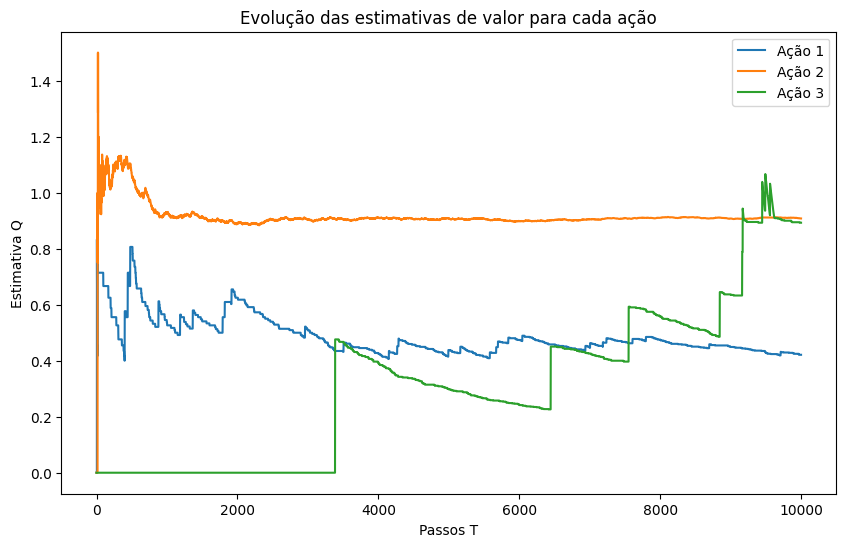

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Número de ações/braços do bandit
k = 3

# Probabilidade de explorar aleatoriamente
epsilon = 0.1

# Número de passos da simulação
steps = 10000

# Probabilidades reais de sucesso de cada braço
probs = np.array([0.1, 0.3, 0.01])

# Recompensa associada a cada braço quando há sucesso
rewards = np.array([5, 3, 50])

# Estimativa de valor Q de cada ação
Q = np.zeros(k)

# Contador de quantas vezes cada ação foi escolhida
N = np.zeros(k)

# Histórico das estimativas ao longo do tempo
history = np.zeros((steps, k))

# Loop principal da simulação
for t in range(steps):
    # Decisão epsilon-greedy:
    # com probabilidade epsilon escolhe aleatoriamente
    if np.random.random() < epsilon:
        action = np.random.randint(k)
    else:
        # caso contrário, escolhe a ação com maior estimativa Q
        action = np.argmax(Q)

    # Sorteia se houve recompensa ou não
    # Se o sorteio for menor que a probabilidade do braço, recebe reward
    reward = rewards[action] if np.random.random() < probs[action] else 0

    # Atualiza o número de vezes que essa ação foi usada
    N[action] += 1

    # Atualiza a estimativa Q pelo método incremental da média
    Q[action] += (reward - Q[action]) / N[action]

    # Guarda o estado atual de Q no histórico
    history[t] = Q.copy()

# Cria a figura do gráfico
plt.figure(figsize=(10, 6))

# Plota a evolução de cada ação
for i in range(k):
    plt.plot(history[:, i], label=f'Ação {i + 1}')

# Nome dos eixos
plt.xlabel('Passos T')
plt.ylabel('Estimativa Q')

# Título do gráfico
plt.title('Evolução das estimativas de valor para cada ação')

# Mostra a legenda
plt.legend()

# Exibe o gráfico
plt.show()